# Build basic 2-Layer MLP to solve the xor-Problem

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs #for data generatio
from sklearn.model_selection import train_test_split #for test set generation
import torch
import torch.nn as nn


In [3]:
X, y = make_blobs(n_samples=200, n_features=2, cluster_std=.1
                  ,centers= [(1,1), (1,0), (0,0),(0,1)])

In [4]:
#make blobs into binary problem
y[y==2]=0
y[y==3]=1

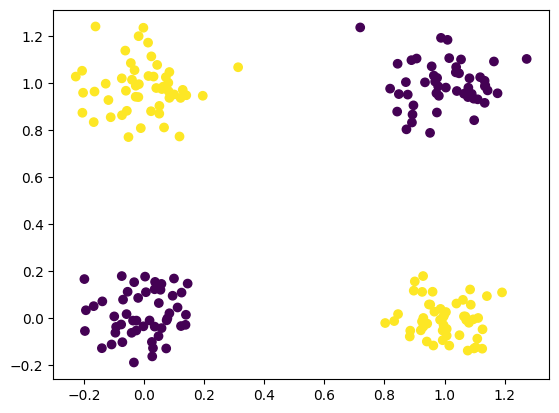

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

## Steps:
* build train and test sets
* write MLP class in Pytorch with two layers with adjustable number of perceptrons
* use nn.linear and nn.Sigmoid() units
* train your model
* test your model

Prepare Training and Test Data


In [6]:
#split in train and test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#np->torch
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

In [7]:
#have look
y_train

tensor([0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1.,
        0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1.,
        1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1.,
        1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 1., 0., 0., 0.,
        1., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0., 1.,
        0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 0., 0., 1., 1.,
        0., 0., 1., 1., 0., 1., 0., 0.])

Build Perceptrons

In [8]:
# Fine Declaration - Maybe nice to make
class MLP2Simple(torch.nn.Module):
    def __init__(self, hiddensize_1):
        super().__init__()
        self.fc1 = torch.nn.Linear(2,hiddensize_1)
        self.sigmoid1 = torch.nn.Sigmoid()

        self.fc2 = torch.nn.Linear(hiddensize_1, 1)







    def forward(self, x):
        # Durch die Schichten propagieren
        x = self.sigmoid1(self.fc1(x))
        x = self.fc2(x)  # Ausgangsschicht
        return x



Get Instance of Model

In [29]:
#get instance of perceptron model
model = MLP2Simple(25)

#define loss function
criterion = torch.nn.CrossEntropyLoss()

#define optimizer -> SGD with learning rate lr
optimizer = torch.optim.SGD(model.parameters(), lr = 0.3)


In [30]:
#run test data theogh untrained model
model.eval() #set to eval mode
model(x_test)

tensor([[0.2526],
        [0.2604],
        [0.2951],
        [0.2170],
        [0.2516],
        [0.2964],
        [0.2565],
        [0.2892],
        [0.2129],
        [0.2534],
        [0.2188],
        [0.2538],
        [0.2177],
        [0.2219],
        [0.3005],
        [0.2188],
        [0.2424],
        [0.2361],
        [0.2938],
        [0.2067],
        [0.2477],
        [0.2947],
        [0.2118],
        [0.2591],
        [0.2207],
        [0.2095],
        [0.2893],
        [0.2906],
        [0.2357],
        [0.2485],
        [0.2568],
        [0.2115],
        [0.2901],
        [0.2414],
        [0.2141],
        [0.2225],
        [0.2906],
        [0.2106],
        [0.2081],
        [0.2520],
        [0.2970],
        [0.2913],
        [0.2534],
        [0.2045],
        [0.2549],
        [0.2527],
        [0.2513],
        [0.2491],
        [0.2427],
        [0.2872],
        [0.2928],
        [0.2414],
        [0.2543],
        [0.2108],
        [0.2114],
        [0

In [31]:
model.train() #set to train mode
epoch = 50
for epoch in range(epoch):
    optimizer.zero_grad()
    # Forward pass
    y_pred = model(x_train)
    # Compute Loss
    loss = criterion(y_pred.squeeze(), y_train)

    print('Epoch {}: train loss: {}'.format(epoch, loss.item()))
    # Backward pass
    loss.backward()
    #make gradient update
    optimizer.step()

Epoch 0: train loss: 352.6849365234375
Epoch 1: train loss: 352.4133605957031
Epoch 2: train loss: 352.1427001953125
Epoch 3: train loss: 351.77587890625
Epoch 4: train loss: 351.1588439941406
Epoch 5: train loss: 349.99920654296875
Epoch 6: train loss: 347.6934814453125
Epoch 7: train loss: 343.39776611328125
Epoch 8: train loss: 341.6416320800781
Epoch 9: train loss: 449.8835144042969
Epoch 10: train loss: 369.5790100097656
Epoch 11: train loss: 430.9614562988281
Epoch 12: train loss: 440.739013671875
Epoch 13: train loss: 427.947998046875
Epoch 14: train loss: 408.7151184082031
Epoch 15: train loss: 411.7033386230469
Epoch 16: train loss: 409.5664367675781
Epoch 17: train loss: 376.7396545410156
Epoch 18: train loss: 441.7978820800781
Epoch 19: train loss: 340.0464172363281
Epoch 20: train loss: 339.2373962402344
Epoch 21: train loss: 338.601318359375
Epoch 22: train loss: 338.0702819824219
Epoch 23: train loss: 337.6104736328125
Epoch 24: train loss: 337.1995849609375
Epoch 25: tra

Evaluate

In [32]:
model.eval() #set model to eval mode

#train
y_pred = model(x_train) #predict
y_pred=(y_pred>0.5).int().flatten() #argmax class lable
train_acc =torch.sum(y_pred == y_train.int())/ y_train.shape[0]
print("train ACC: ",train_acc.float())

train ACC:  tensor(0.9701)


In [33]:
#test
y_pred = model(x_test) #predict
y_pred=(y_pred>0.5).int().flatten() #argmax class lable
test_acc = torch.sum(y_pred == y_test.int()) / y_test.shape[0]
print("test ACC: ",test_acc.float())

test ACC:  tensor(0.9697)


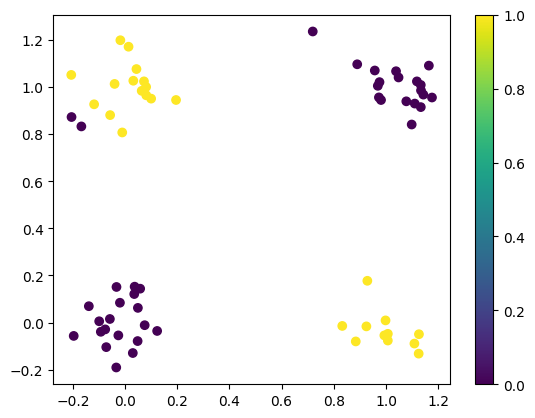

In [34]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_pred)
plt.colorbar()